In [5]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from anngeno import AnnGeno
import multiprocessing

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

num_cores = multiprocessing.cpu_count()
print(num_cores)

16


In [6]:
# Configuration and paths
corr_method = 'spearman'
trait_type = 'quantitative'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 100

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac


759.292

In [7]:
config_path = f'/home/dnanexus/ukbgym/config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)

# Collect annotation categories
all_annotation_list = []
rare_variant_annotations_dict = config.get("rare_variant_annotations")
if rare_variant_annotations_dict:
    for category in rare_variant_annotations_dict.values():
        all_annotation_list.extend(category)

In [8]:
appv = pl.read_parquet("/home/dnanexus/data_dir/avg_pheno_per_var_quantitative_EUR_genebass1e6coding.parquet")
appv = appv.filter(pl.col('n_individuals')<=mac)
appv

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value
str,str,u32,f32,f32
"""chr1:3476029:G:A""","""red_blood_cell_erythrocyte_dis…",19,-0.347493,0.960577
"""chr1:2229460:C:T""","""red_blood_cell_erythrocyte_dis…",1,0.426851,null
"""chr1:10072146:G:A""","""red_blood_cell_erythrocyte_dis…",22,-0.12495,0.843646
"""chr1:3463318:G:A""","""mean_platelet_thrombocyte_volu…",128,-0.015066,0.846027
"""chr1:2515618:C:T""","""mean_platelet_thrombocyte_volu…",98,0.011947,0.797165
…,…,…,…,…
"""chr22:50454662:G:A""","""microalbumin_in_urine_int""",1,-0.803816,null
"""chr22:50455057:C:G""","""mothers_age_at_death_int""",1,1.928162,null
"""chr22:50283981:T:C""","""mothers_age_at_death_int""",1,1.303833,null


In [9]:
anno = pl.read_parquet("/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag/annotations.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.columns]

anno = anno.with_columns(
    (pl.col('consequence_missense_variant') == 1)
).select(
    set(['id', 'region']).union(set(existing_annos))
).filter(
    pl.col('id').is_in(appv['id'].unique())
)

melted_anno = anno.unpivot(
    index=["id", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
    # pl.col("af_ukb").cast(pl.Float32)
)

melted_anno

/tmp/ipykernel_7966/1718422457.py:9: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score
str,str,str,f32
"""chr1:169795116:G:C""","""ENSG00000000460""","""cadd_raw""",2.172202
"""chr1:169798959:G:A""","""ENSG00000000460""","""cadd_raw""",6.18842
"""chr1:169798959:G:GT""","""ENSG00000000460""","""cadd_raw""",0.0
"""chr1:169798959:G:T""","""ENSG00000000460""","""cadd_raw""",5.926235
"""chr1:169800908:G:A""","""ENSG00000000460""","""cadd_raw""",3.04392
…,…,…,…
"""chr7:151061964:A:G""","""ENSG00000288608""","""relprotpos""",0.812
"""chr7:151061966:C:T""","""ENSG00000288608""","""relprotpos""",0.812
"""chr7:151061967:GA:G""","""ENSG00000288608""","""relprotpos""",0.0


In [13]:
melted_anno['id'].n_unique(), melted_anno.shape[0]

(1203541, 10284216)

In [10]:
a = pl.read_parquet('/home/dnanexus/data_dir/genebass_continuous_associations_ukbbgym.pq').with_columns(
    (pl.col('description').str.replace_all(r"\(", "").str.replace_all(r"\)", "").str.replace_all(' ', '_').str.to_lowercase() + '_int').alias('phenotype'),
    pl.col('gene_id').alias('region'),
    pl.col('gene_symbol').alias('gene_name')
).filter(
    (pl.col('annotation').str.contains('pLoF')) &
    # (pl.col('annotation') == 'pLoF') &
    (pl.col('phenotype').is_in(appv['phenotype'].unique())) &
    (pl.col('region').is_in(anno['region'].unique()))
)

# Keep the top hit per gene
a = a.sort("Pvalue").unique(subset=["region"], keep="first")

gene_trait_df = a[['region', 'gene_id', 'gene_name', 'phenotype', 'trait_type']].unique()

# Get beta directions
plof = pl.read_parquet('/home/dnanexus/data_dir/rvat_EUR_500k_regenie.parquet').with_columns(
    (pl.col('trait') + '_int').alias('phenotype'),
    pl.col('gene_id').alias('region')
)
gene_trait_df = gene_trait_df.join(plof[['region', 'phenotype', 'beta']], on=['region', 'phenotype'], how='inner')

gene_trait_df

/tmp/ipykernel_7966/327114618.py:5: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


region,gene_id,gene_name,phenotype,trait_type,beta
str,str,str,str,str,f64
"""ENSG00000173575""","""ENSG00000173575""","""CHD2""","""lymphocyte_percentage_int""","""continuous""",0.0271693
"""ENSG00000196712""","""ENSG00000196712""","""NF1""","""lymphocyte_percentage_int""","""continuous""",-0.792415
"""ENSG00000183153""","""ENSG00000183153""","""GJD3""","""lymphocyte_percentage_int""","""continuous""",-0.015211
"""ENSG00000152242""","""ENSG00000152242""","""C18orf25""","""lymphocyte_percentage_int""","""continuous""",-0.170487
"""ENSG00000118046""","""ENSG00000118046""","""STK11""","""lymphocyte_percentage_int""","""continuous""",-1.06188
…,…,…,…,…,…
"""ENSG00000197969""","""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""","""continuous""",0.176348
"""ENSG00000106868""","""ENSG00000106868""","""SUSD1""","""reticulocyte_count_int""","""continuous""",0.18551
"""ENSG00000162337""","""ENSG00000162337""","""LRP5""","""heel_bone_mineral_density_bmd_…","""continuous""",-0.794196


In [11]:
gene_trait_df['region'].n_unique(), gene_trait_df.shape[0]

(1056, 3077)

In [14]:
# Filter annotations and appv to those in gene_trait_df
anno_flt = melted_anno.filter(
    pl.col('region').is_in(gene_trait_df['region'].unique())
).drop([c for c in anno.columns if 'is_nan' in c])

appv_flt = appv.filter(
    pl.col('id').is_in(anno_flt['id'].unique())
).drop('std_pheno_value').drop_nulls()

print(anno_flt.shape, appv_flt.shape)

# Join df all the dataframes with pairs to restrict to valid 
pheno_anno = (
    appv_flt.lazy()
    .join(anno_flt.lazy(), on="id", how="inner")
    .join(gene_trait_df.lazy(), on=["region", "phenotype"], how="inner")
    .collect(engine='streaming')
)

print(pheno_anno.shape)

# Rank the mean phenotype values and annotation scores
rank_expressions = [
    pl.col(c)
    .rank("ordinal")
    .over(["region", "phenotype", "annotation"])
    .alias(f"{c}_rank")
    for c in ['mean_pheno_value', 'annotation_score']
]

# Apply the window expressions with .with_columns()
pheno_anno = pheno_anno.with_columns(rank_expressions)

/tmp/ipykernel_7966/3381029561.py:2: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_7966/3381029561.py:6: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


(6176328, 4) (82315973, 4)
(19528712, 11)


In [16]:
pheno_anno['id'].n_unique(), pheno_anno.shape[0]

(699196, 19528712)

In [8]:
correlation_df = (
    pheno_anno
    .group_by(["region", "gene_name", "phenotype", "annotation"])
    .agg(
        pl.col("id").count().alias("n_variants"),
        pl.corr(pl.col("mean_pheno_value_rank"), pl.col("annotation_score_rank")).alias("correlation")
    ).with_columns(
        pl.col("correlation").abs().alias("abs_corr"),
    )
)

# Check if the variant counts are consistent within each (region, phenotype) pair
inconsistent = (
    correlation_df
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {inconsistent.shape[0]}")

correlation_df

Inconsistent (region, phenotype) pairs: 0


region,gene_name,phenotype,annotation,n_variants,correlation,abs_corr
str,str,str,str,u32,f64,f64
"""ENSG00000111266""","""DUSP16""","""standing_height_int""","""cadd_raw""",493,0.047826,0.047826
"""ENSG00000143436""","""MRPL9""","""vitamin_d_int""","""esmscoremissense""",233,0.058965,0.058965
"""ENSG00000177628""","""GBA""","""haematocrit_percentage_int""","""cadd_raw""",333,-0.057739,0.057739
"""ENSG00000142082""","""SIRT3""","""mean_platelet_thrombocyte_volu…","""esmscoremissense""",672,-0.043444,0.043444
"""ENSG00000169676""","""DRD5""","""urate_int""","""esmscoremissense""",480,-0.004913,0.004913
…,…,…,…,…,…,…
"""ENSG00000167895""","""TMC8""","""glycated_haemoglobin_hba1c_int""","""gpn_score""",636,0.022287,0.022287
"""ENSG00000136859""","""ANGPTL2""","""standing_height_int""","""gpn_score""",427,0.199656,0.199656
"""ENSG00000144152""","""FBLN7""","""sitting_height_int""","""am_pathogenicity""",420,-0.024669,0.024669


/tmp/ipykernel_1043666/2591750578.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


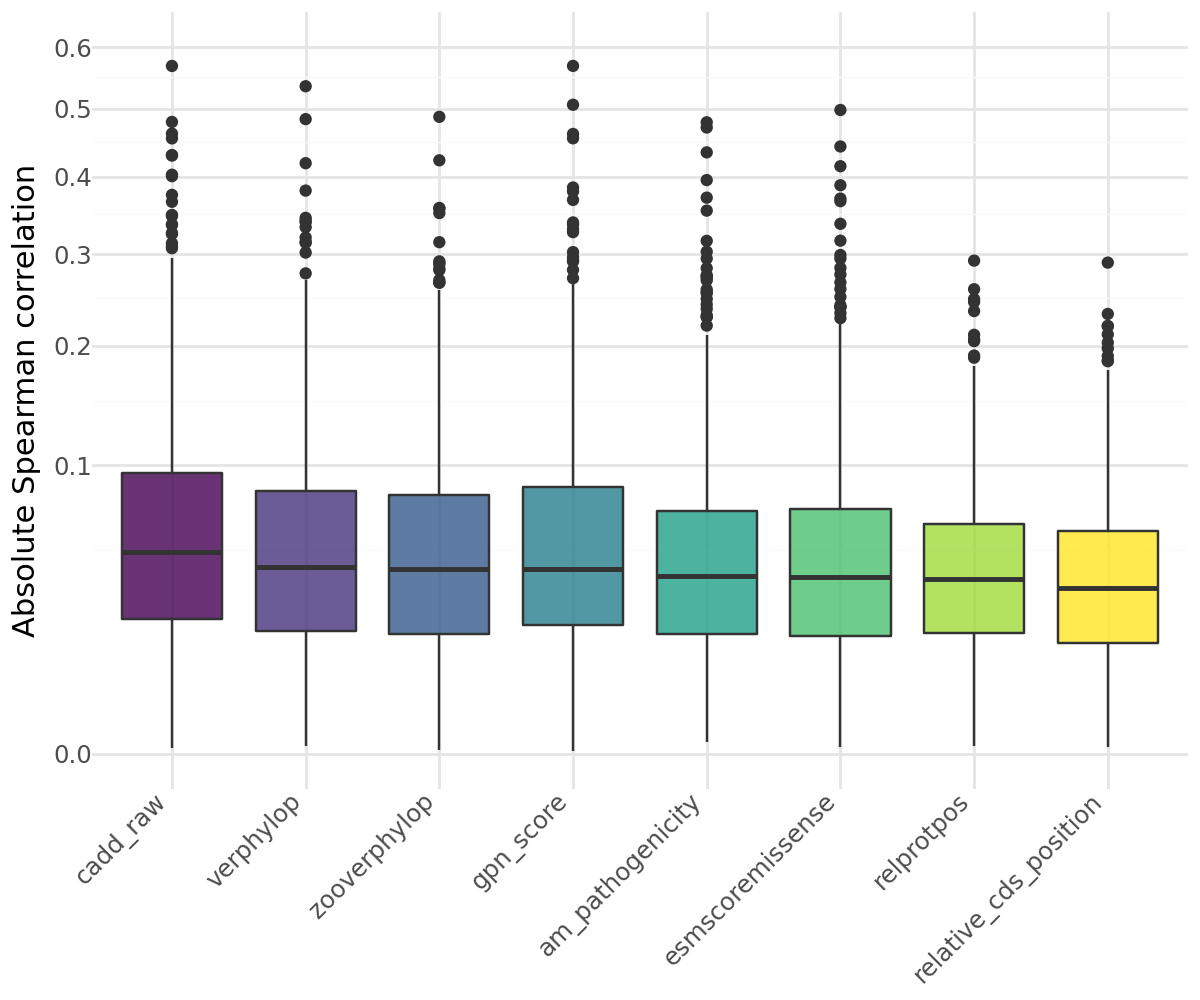

In [9]:
med_df = correlation_df.drop_nans().group_by("annotation").agg([
    pl.col("abs_corr").median().alias("median_abs_corr"),
    # pl.col("rel_abs_corr").median().alias("median_rel_abs_corr")
])

corr_pd = med_df.join(correlation_df, on='annotation').to_pandas()

corr_pd['annotation'] = pd.Categorical(
    corr_pd['annotation'],
    categories=corr_pd.sort_values('median_abs_corr', ascending=False)['annotation'].unique(),
    ordered=True
)

# Define colors
order = corr_pd['annotation'].cat.categories.to_list()
cmap = plt.cm.get_cmap("viridis", len(order))
color_dict = dict(zip(order, [mcolors.to_hex(cmap(i)) for i in range(len(order))]))

# Plot
(
    ggplot(corr_pd, aes(x='annotation', y='abs_corr', fill='annotation')) +
    geom_boxplot(alpha=0.8) +
    theme_minimal() +
    scale_y_sqrt(limits=[0, 0.6], breaks=[b*0.1 for b in range(7)]) +
    scale_fill_manual(values=color_dict) +
    labs(
        x='',
        y='Absolute Spearman correlation'
    ) +
    theme(
        figure_size=(6, 5),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

### Single gene-trait association plot

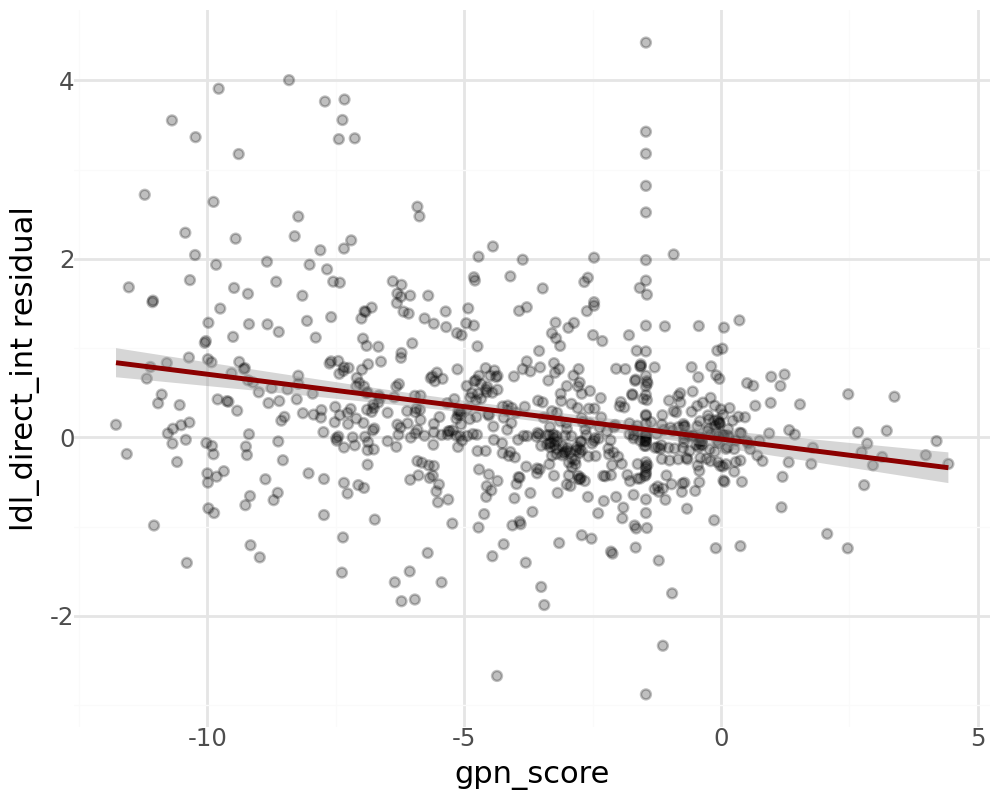

In [10]:
method = 'pearson'
annotation = 'gpn_score'
gene_name = 'LDLR'
phenotype = 'ldl_direct_int'

sc_df = pheno_anno.filter(
    (pl.col('phenotype') == phenotype) &
    (pl.col('gene_name') == gene_name) &
    (pl.col('annotation') == annotation)
)

(
    ggplot(sc_df, aes(x='annotation_score', y='mean_pheno_value')) +
    geom_point(alpha=0.25) +
    geom_smooth(method='lm', se=True, color='darkred') +
    theme_minimal() +
    labs(
        x=f"{annotation}",
        y=f"{phenotype} residual"
    ) +
    theme(figure_size=(5, 4))
)

### Facet by n_vars

In [25]:
n_cuts = 10
corr_pd['n_var_quantile'] = pd.qcut(corr_pd['n_variants'], n_cuts, labels=[f'{i}' for i in range(1, n_cuts+1)])
corr_pd['n_var_quantile'].value_counts()

n_var_quantile
1     856
3     848
9     848
5     848
6     848
7     848
2     840
4     840
10    840
8     832
Name: count, dtype: int64

/tmp/ipykernel_1043666/3809464156.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


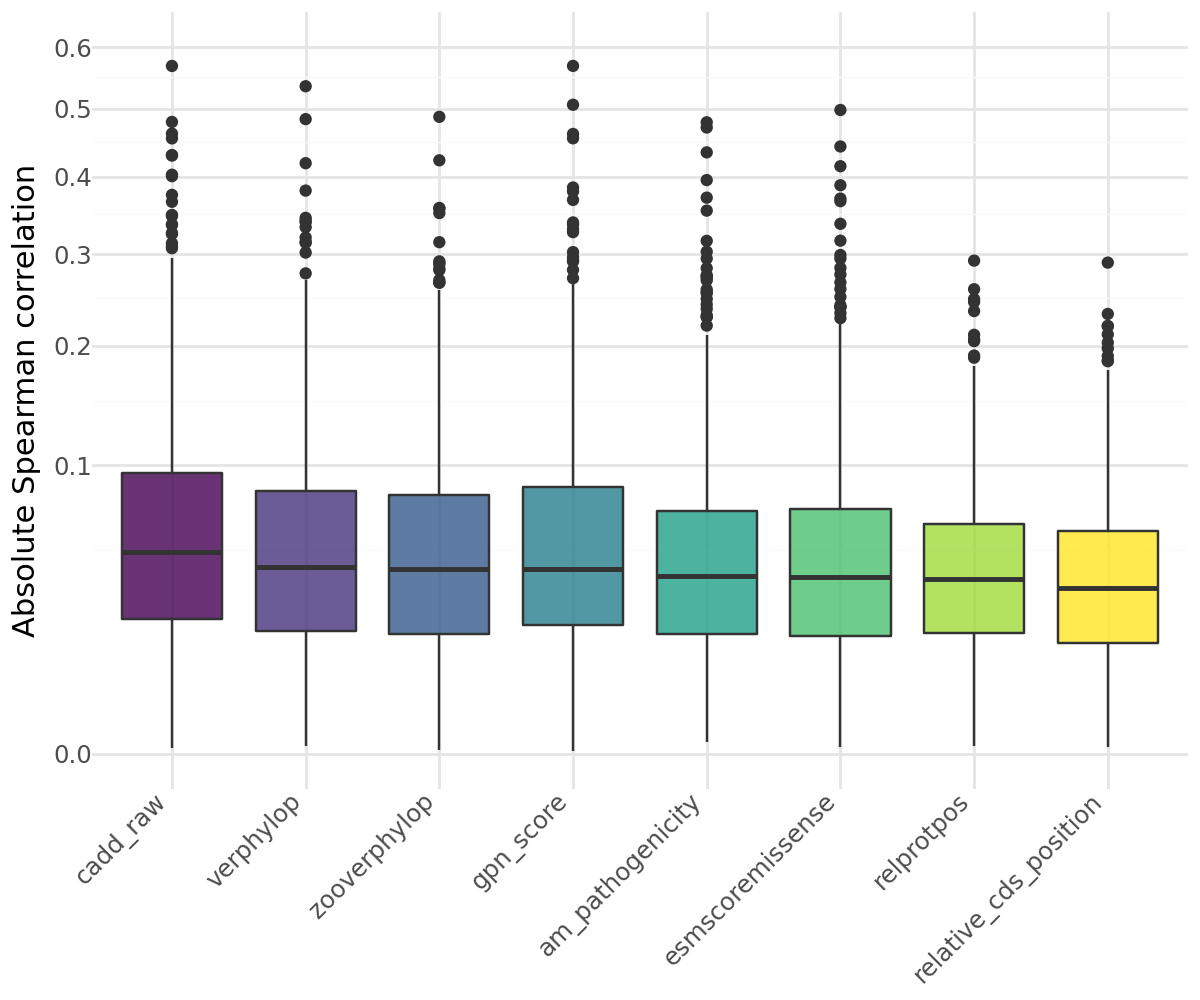

In [28]:
corr_q1 = corr_pd[corr_pd[f'n_var_quantile']=='1']

med_df = (
    corr_q1
    .groupby("annotation", as_index=False)
    .agg(median_abs_corr_lq=("abs_corr", "median"))
)

corr_q1 = corr_q1.merge(med_df, on='annotation')
order = corr_q1.sort_values("median_abs_corr_lq", ascending=False)["annotation"].unique()

(
    ggplot(corr_pd, aes(x='annotation', y='abs_corr', fill='annotation')) +
    geom_boxplot(alpha=0.8) +
    theme_minimal() +
    scale_y_sqrt(limits=[0, 0.6], breaks=[b*0.1 for b in range(7)]) +
    scale_fill_manual(values=color_dict) +
    labs(
        x='',
        y='Absolute Spearman correlation'
    ) +
    theme(
        figure_size=(6, 5),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

## Facet by LOEUF

In [16]:
# gene_property = 'lof.oe_ci.upper'
gene_property = 'cds_length'

gn = pl.read_csv(
    '/home/dnanexus/data_dir/gnomad.v4.1.constraint_metrics.tsv', 
    null_values='NA',
    separator='\t'
).filter(
    (pl.col('mane_select') == True) &
    (pl.col('transcript_type') == 'protein_coding')
).with_columns(
    pl.col(gene_property).qcut(10, labels=[f'{i}' for i in range(1, 11)]).alias(f'{gene_property}_decile')
).to_pandas()

gn

,gene,gene_id,transcript,canonical,mane_select,lof_hc_lc.obs,lof_hc_lc.exp,lof_hc_lc.possible,lof_hc_lc.oe,lof_hc_lc.mu,...,syn.oe_ci.upper,syn.z_raw,syn.z_score,constraint_flags,level,transcript_type,chromosome,cds_length,num_coding_exons,cds_length_decile
0,A1BG,ENSG00000121410,ENST00000263100,True,True,45.0,43.0480,193.0,1.04540,7.063300e-07,...,1.172,-1.166000,-0.635490,[],2,protein_coding,chr19,1485,8,6
1,A1CF,ENSG00000148584,ENST00000373997,True,True,45.0,69.9620,352.0,0.64320,9.547100e-07,...,1.103,0.032727,0.017838,[],2,protein_coding,chr10,1758,11,7
2,A2M,ENSG00000175899,ENST00000318602,True,True,95.0,147.2400,745.0,0.64522,1.344500e-06,...,0.929,3.368800,1.836200,[],2,protein_coding,chr12,4422,36,10
3,A2ML1,ENSG00000166535,ENST00000299698,True,True,146.0,176.0500,881.0,0.82930,1.700700e-06,...,0.996,1.745200,0.951210,[],2,protein_coding,chr12,4362,35,10
4,A3GALT2,ENSG00000184389,ENST00000442999,True,True,41.0,26.5590,110.0,1.54380,3.376300e-07,...,1.753,-7.333400,-3.997000,"[""outlier_mis""]",2,protein_coding,chr1,1020,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17476,None,ENSG00000284024,ENST00000640019,True,True,23.0,33.3410,150.0,0.68984,9.153200e-07,...,1.075,0.716050,0.390280,[],2,protein_coding,chr10,1083,2,4
17477,None,ENSG00000285043,ENST00000338110,True,True,9.0,19.2800,89.0,0.46680,1.504500e-07,...,NaN,NaN,NaN,"[""no_exp_lof"",""no_exp_mis"",""no_exp_syn"",""no_va...",2,protein_coding,chr16,417,4,1
17478,None,ENSG00000286135,ENST00000652090,True,True,0.0,1.4471,8.0,0.00000,2.520600e-08,...,1.067,1.581300,0.861890,[],2,protein_coding,chr10,411,4,1
17479,None,ENSG00000286190,ENST00000568641,True,True,4.0,3.2926,20.0,1.21480,4.915500e-08,...,1.570,-2.406500,-1.311700,[],2,protein_coding,chr17,357,1,1


In [17]:
corr_lf = corr_pd.merge(
    gn[['gene_id', gene_property, f'{gene_property}_decile']], left_on='region', right_on='gene_id', how='left')

corr_lf = corr_lf.dropna()
corr_lf

,annotation,median_abs_corr,region,gene_name,phenotype,n_variants,correlation,abs_corr,gene_id,cds_length,cds_length_decile
0,cadd_raw,0.048888,ENSG00000111266,DUSP16,standing_height_int,493,0.047826,0.047826,ENSG00000111266,1995.0,8
1,esmscoremissense,0.037467,ENSG00000143436,MRPL9,vitamin_d_int,233,0.058965,0.058965,ENSG00000143436,801.0,3
2,cadd_raw,0.048888,ENSG00000177628,GBA,haematocrit_percentage_int,333,-0.057739,0.057739,ENSG00000177628,1608.0,7
3,esmscoremissense,0.037467,ENSG00000142082,SIRT3,mean_platelet_thrombocyte_volume_int,672,-0.043444,0.043444,ENSG00000142082,1197.0,5
4,esmscoremissense,0.037467,ENSG00000169676,DRD5,urate_int,480,-0.004913,0.004913,ENSG00000169676,1431.0,6
...,...,...,...,...,...,...,...,...,...,...,...
8443,gpn_score,0.041156,ENSG00000167895,TMC8,glycated_haemoglobin_hba1c_int,636,0.022287,0.022287,ENSG00000167895,2178.0,8
8444,gpn_score,0.041156,ENSG00000136859,ANGPTL2,standing_height_int,427,0.199656,0.199656,ENSG00000136859,1479.0,6
8445,am_pathogenicity,0.037880,ENSG00000144152,FBLN7,sitting_height_int,420,-0.024669,0.024669,ENSG00000144152,1317.0,5
8446,esmscoremissense,0.037467,ENSG00000166526,ZNF3,haemoglobin_concentration_int,343,0.074992,0.074992,ENSG00000166526,1338.0,6


In [18]:
corr_lf[['region', 'phenotype', f'{gene_property}_decile']].drop_duplicates()[f'{gene_property}_decile'].value_counts(sort=True)

cds_length_decile
10    216
9     145
8     122
6     116
7     109
5      97
4      78
3      59
2      53
1      48
Name: count, dtype: int64

/tmp/ipykernel_1043666/3299248181.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


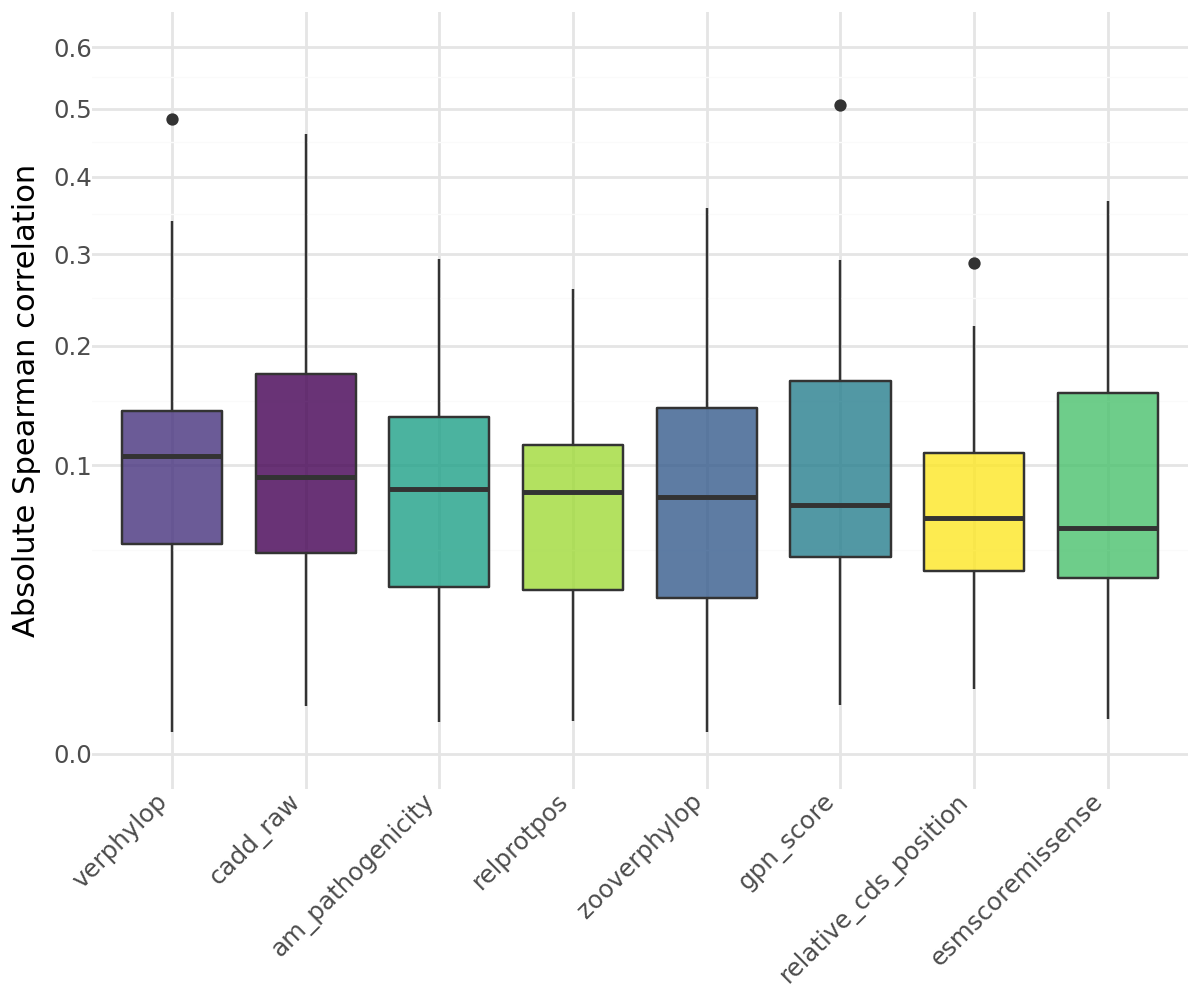

In [19]:
corr_q1 = corr_lf[corr_lf[f'{gene_property}_decile']=='1']

med_df = (
    corr_q1
    .groupby("annotation", as_index=False)
    .agg(median_abs_corr_lq=("abs_corr", "median"))
)

corr_q1 = corr_q1.merge(med_df, on='annotation')
order = corr_q1.sort_values("median_abs_corr_lq", ascending=False)["annotation"].unique()

# Plot
(
    ggplot(corr_q1, aes(x='annotation', y='abs_corr', fill='annotation')) +
    geom_boxplot(alpha=0.8) +
    theme_minimal() +
    scale_y_sqrt(limits=[0, 0.6], breaks=[b*0.1 for b in range(7)]) +
    scale_x_discrete(limits=order) +
    scale_fill_manual(values=color_dict) +
    labs(
        x='',
        y='Absolute Spearman correlation'
    ) +
    theme(
        figure_size=(6, 5),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

/tmp/ipykernel_1043666/2741533682.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


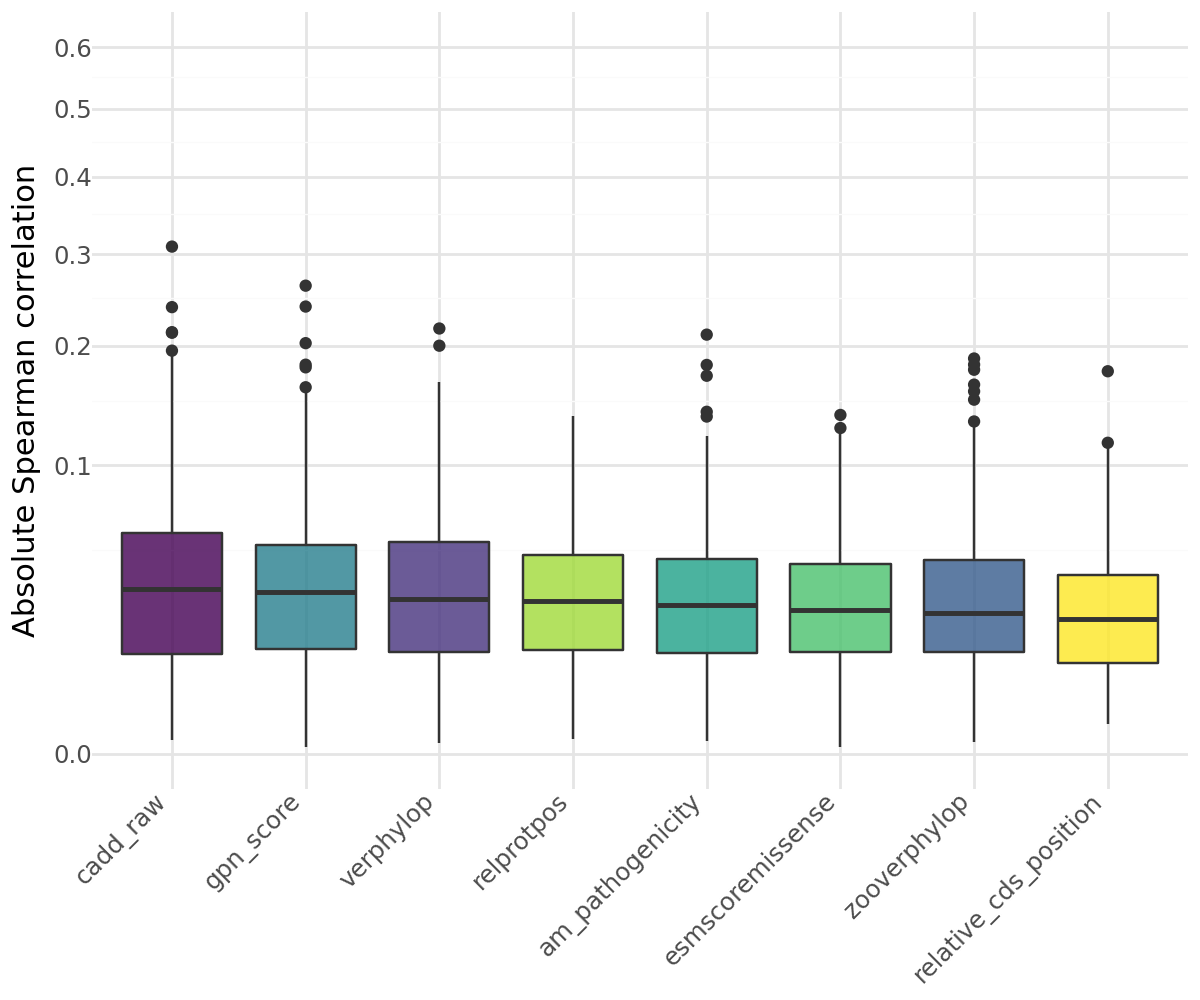

In [20]:
corr_q10 = corr_lf[corr_lf[f'{gene_property}_decile']=='10']

med_df = (
    corr_q10
    .groupby("annotation", as_index=False)
    .agg(median_abs_corr_lq=("abs_corr", "median"))
)

corr_q10 = corr_q10.merge(med_df, on='annotation')
order = corr_q10.sort_values("median_abs_corr_lq", ascending=False)["annotation"].unique()

# Plot
(
    ggplot(corr_q10, aes(x='annotation', y='abs_corr', fill='annotation')) +
    geom_boxplot(alpha=0.8) +
    theme_minimal() +
    scale_y_sqrt(limits=[0, 0.6], breaks=[b*0.1 for b in range(7)]) +
    scale_x_discrete(limits=order) +
    scale_fill_manual(values=color_dict) +
    labs(
        x='',
        y='Absolute Spearman correlation'
    ) +
    theme(
        figure_size=(6, 5),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

## Enrichment of true extremes in predicted extremes

In [ ]:
ct_df = pheno_anno.group_by(
    ["region", "gene_name", "phenotype", "annotation"]
).agg(
    pl.col("id").count().alias("n_variants"),
)

xtm_df = pheno_anno.join(ct_df, on=["region", "gene_name", "phenotype", "annotation"], how="left")

# Restrict to postive associations
# pos_assoc= gene_trait_df.filter(pl.col('beta')>0)
# xtm_df = xtm_df.join(pos_assoc[['region', 'phenotype']], on=['region', 'phenotype'], how='inner')
gene_trait_df = gene_trait_df.with_columns(
    (pl.col('beta')/pl.col('beta').abs()).alias('beta_dir')
)
xtm_df = xtm_df.join(gene_trait_df[['region', 'phenotype', 'beta_dir']], on=['region', 'phenotype'], how='inner')

xtm_df = xtm_df.with_columns(
    (pl.col("mean_pheno_value") * pl.col("beta_dir")).alias("mean_pheno_value_same_dir"),
    (pl.col("annotation_score_rank") / pl.col("n_variants")).alias("annotation_score_ptile")
)

rev_df = xtm_df.filter(pl.col('annotation')=='gpn_score').with_columns(
    (1-pl.col('annotation_score_ptile')).alias('annotation_score_ptile'),
    pl.lit('gpn_score_rev').alias('annotation')
)

xtm_df = pl.concat([xtm_df, rev_df])
xtm_df

id,phenotype,n_individuals,mean_pheno_value,region,annotation,annotation_score,gene_id,gene_name,trait_type,beta,mean_pheno_value_rank,annotation_score_rank,n_variants,beta_dir,mean_pheno_value_same_dir,annotation_score_ptile
str,str,u32,f32,str,str,f32,str,str,str,f64,u32,u32,u32,f64,f64,f64
"""chr1:62604150:T:C""","""apolipoprotein_b_int""",35,-0.093685,"""ENSG00000132855""","""cadd_raw""",-0.694496,"""ENSG00000132855""","""ANGPTL3""","""continuous""",-0.193428,137,5,308,-1.0,0.093685,0.016234
"""chr1:62604150:T:C""","""apolipoprotein_b_int""",35,-0.093685,"""ENSG00000132855""","""verphylop""",-2.182,"""ENSG00000132855""","""ANGPTL3""","""continuous""",-0.193428,137,7,308,-1.0,0.093685,0.022727
"""chr1:62604150:T:C""","""apolipoprotein_b_int""",35,-0.093685,"""ENSG00000132855""","""esmscoremissense""",0.0,"""ENSG00000132855""","""ANGPTL3""","""continuous""",-0.193428,137,187,308,-1.0,0.093685,0.607143
"""chr1:62604150:T:C""","""apolipoprotein_b_int""",35,-0.093685,"""ENSG00000132855""","""am_pathogenicity""",0.0,"""ENSG00000132855""","""ANGPTL3""","""continuous""",-0.193428,137,1,308,-1.0,0.093685,0.003247
"""chr1:62604150:T:C""","""apolipoprotein_b_int""",35,-0.093685,"""ENSG00000132855""","""relative_cds_position""",0.8,"""ENSG00000132855""","""ANGPTL3""","""continuous""",-0.193428,137,245,308,-1.0,0.093685,0.795455
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr22:36295046:C:T""","""reticulocyte_percentage_int""",12,0.558347,"""ENSG00000100345""","""gpn_score_rev""",-4.02,"""ENSG00000100345""","""MYH9""","""continuous""",-0.453329,1066,835,1284,-1.0,-0.558347,0.349688
"""chr22:36319592:G:A""","""high_light_scatter_reticulocyt…",2,-0.163427,"""ENSG00000100345""","""gpn_score_rev""",-1.28,"""ENSG00000100345""","""MYH9""","""continuous""",-0.428117,476,1110,1284,-1.0,0.163427,0.135514
"""chr22:36322432:G:C""","""high_light_scatter_reticulocyt…",1,-0.132964,"""ENSG00000100345""","""gpn_score_rev""",-2.93,"""ENSG00000100345""","""MYH9""","""continuous""",-0.428117,501,1016,1284,-1.0,0.132964,0.208723


In [567]:
pred_cutoff = 0.1
xtm_df = xtm_df.with_columns(
        (pl.col("annotation_score_ptile") <= pred_cutoff).alias("low_predicted"),
        (pl.col("annotation_score_ptile") >= 1 - pred_cutoff).alias("high_predicted"),
)

enr_df_list = []
for z_alpha in tqdm(range(300)):
    z_score = z_alpha/100
    pr_temp = xtm_df.filter(
        (pl.col("mean_pheno_value") >= z_score)
    ).group_by(
        ["annotation", "region", "phenotype"]
    ).agg(
        (pl.count().alias("high_true")),
        (pl.col("high_predicted").sum()).alias("high_correct"),
        
    ).with_columns(
        (pl.col("high_correct") / pl.col("high_true")).alias("high_enrichment"),
        pl.lit(z_score).alias('z_score')
    )

    enr_df_list.append(pr_temp)

enr_df = pl.concat(enr_df_list)
enr_df

  0%|          | 0/300 [00:00<?, ?it/s]

/tmp/ipykernel_357527/1331981619.py:15: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
100%|██████████| 300/300 [00:21<00:00, 13.94it/s]


annotation,region,phenotype,high_true,high_correct,high_enrichment,z_score
str,str,str,u32,u32,f64,f64
"""cadd_raw""","""ENSG00000204301""","""lymphocyte_count_int""",816,84,0.102941,0.0
"""gpn_score""","""ENSG00000024048""","""arm_fat_percentage_right_int""",547,54,0.09872,0.0
"""am_pathogenicity""","""ENSG00000168496""","""leg_predicted_mass_left_int""",132,12,0.090909,0.0
"""cadd_raw""","""ENSG00000244734""","""red_blood_cell_erythrocyte_dis…",62,9,0.145161,0.0
"""am_pathogenicity""","""ENSG00000163631""","""cholesterol_int""",238,30,0.12605,0.0
…,…,…,…,…,…,…
"""gpn_score""","""ENSG00000204520""","""seated_height_int""",1,0,0.0,2.99
"""gpn_score""","""ENSG00000173575""","""lymphocyte_count_int""",11,3,0.272727,2.99
"""esmscoremissense""","""ENSG00000120889""","""mean_corpuscular_volume_int""",2,0,0.0,2.99


In [568]:
annos_to_keep = [
    # 'zoopriphylop',
 'verphylop',
#  'relprotpos',
#  'mamphcons',
 'zooverphylop',
#  'mamphylop',
 'gpn_score',
 'gpn_score_rev',
 'relative_cds_position',
 'esmscoremissense',
#  'priphylop',
 'cadd_raw',
#  'priphcons',
#  'af_ukb',
#  'verphcons',
 'am_pathogenicity'
 ]

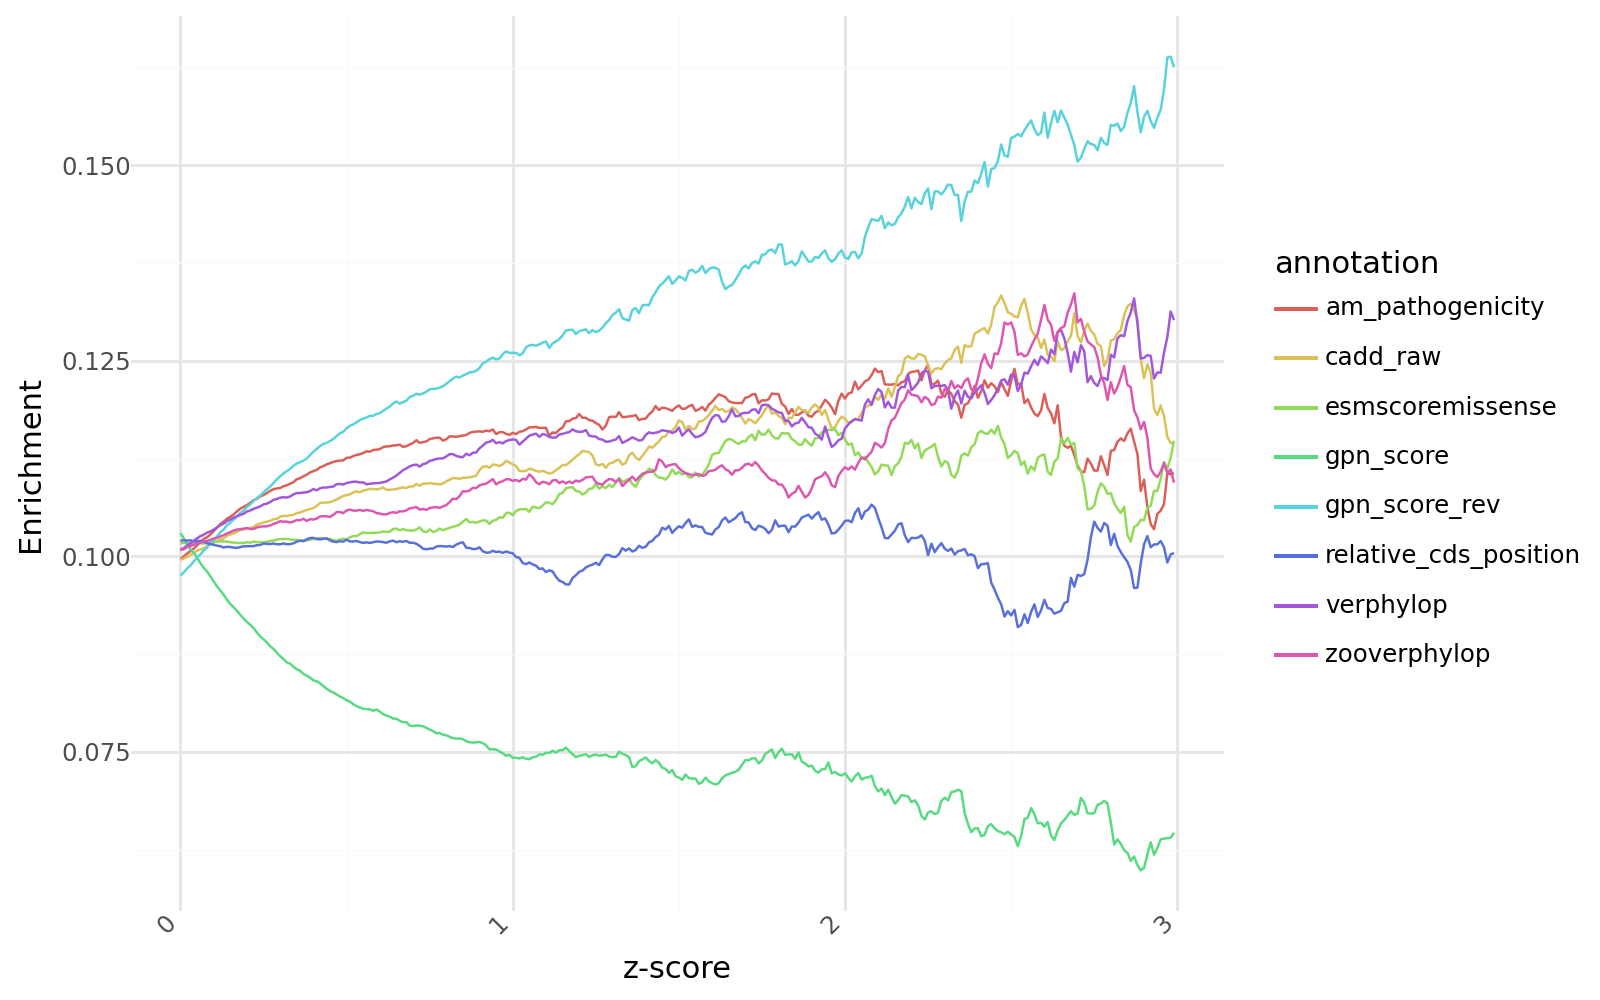

In [569]:
plot_df = enr_df.group_by('annotation', 'z_score').agg(pl.col('high_enrichment').mean())

(
    ggplot(plot_df.filter(pl.col('annotation').is_in(annos_to_keep)), aes(x='z_score', y='high_enrichment', color='annotation')) +
    geom_line() +
    # theme_538() +
    theme_minimal() +
    # scale_color_manual(values=color_dict) +
    labs(
        x='z-score',
        y='Enrichment'
    ) +
    theme(
        figure_size=(8, 5),
        # legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)